In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ELECTRONIC_SALES_DATASET = "data/Electronic_sales_Sep2023-Sep2024.csv"

## Задание 1
На основании датасета для каждого покупателя получите:

- предпочитаемый метод оплаты;
- общие траты;
- количество денег, потраченных на дополнительные услуги и аксессуары. 


In [3]:
data = pd.read_csv(ELECTRONIC_SALES_DATASET)
data.head()

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56


In [4]:
df = data.groupby('Customer ID').agg({
    'Payment Method': lambda x: x.value_counts().idxmax(),
    "Total Price": "sum",
    'Add-on Total': 'sum',
})
df.rename(columns={
    'Payment Method': 'Preferred Payment Method',
    'Total Price': 'Total expenses',
    'Add-on Total': 'Total add-on expenses',
}, inplace=True)
df.head(10)

,Preferred Payment Method,Total expenses,Total add-on expenses
Customer ID,,,
1000,Credit Card,6279.42,66.30
1002,Credit Card,5020.60,60.16
1003,Cash,41.50,35.56
1004,Credit Card,83.00,65.78
1005,Paypal,11779.11,75.33
1006,Debit Card,12184.27,133.43
1007,Credit Card,7120.71,55.48
1008,Cash,3379.32,65.85
1011,Credit Card,7911.90,70.17


## Задание 2

### 1 На основании датасета получите доход:
- по каждому методу доставки, 
- по каждому типу продукта, 
- по дополнительным услугам за каждый месяц,
- по дополнительным услугам за каждый квартал. 

### 2 Отобразите полученные данные на графике

In [33]:
# Доход (Income) от каждой покупки - это сумма цены товара + цены аксессуаров.
# Однако, если доставка была отменена, то доход от сделки считаю равным 0 тк деньги обычно возвращают в таких ситуациях 

data['Income'] = (data['Total Price'] + data['Add-on Total']) * data['Order Status'].map({'Cancelled': 0, 'Completed': 1})
data['Purchase Month'] = pd.to_datetime(data['Purchase Date']).dt.month_name()
data['Purchase Quarter'] = pd.to_datetime(data['Purchase Date']).dt.quarter.map({1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'})
data.head()

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total,Income,Purchase Month,Purchase Quarter
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21,0.00,March,Q1
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09,767.18,April,Q2
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00,1855.84,October,Q4
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16,3224.92,August,Q3
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56,77.06,May,Q2


### 2.1 Доход по каждому методу доставки

In [34]:
df = data[['Shipping Type', 'Income']].groupby('Shipping Type').agg({'Income': 'sum'}).reset_index()
df.head(10)

,Shipping Type,Income
0,Expedited,8610437.09
1,Express,5725863.77
2,Overnight,5982983.40
3,Same Day,8469574.60
4,Standard,14676351.95


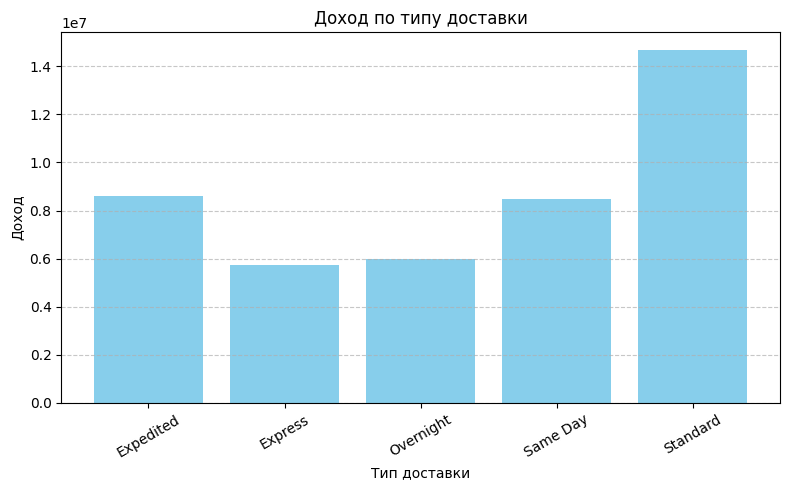

In [35]:
plt.figure(figsize=(8, 5))
plt.bar(df['Shipping Type'], df['Income'], color='skyblue')
plt.title('Доход по типу доставки')
plt.xlabel('Тип доставки')
plt.ylabel('Доход')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 2.2 Доход по каждому типу продукта

In [36]:
df = data[['Product Type', 'Income']].groupby('Product Type').agg({'Income': 'sum'}).reset_index()
df.head(10)

,Product Type,Income
0,Headphones,2847454.72
1,Laptop,8536583.03
2,Smartphone,14630325.53
3,Smartwatch,9557416.02
4,Tablet,7893431.51


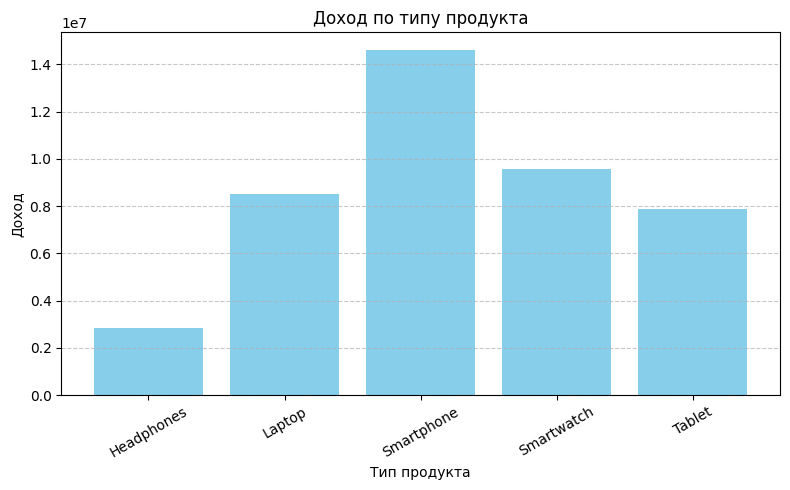

In [37]:
plt.figure(figsize=(8, 5))
plt.bar(df['Product Type'], df['Income'], color='skyblue')
plt.title('Доход по типу продукта')
plt.xlabel('Тип продукта')
plt.ylabel('Доход')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 2.3 Доход по дополнительным услугам за каждый месяц

In [38]:
df = data[['Purchase Month', 'Add-on Total']].groupby('Purchase Month').agg({'Add-on Total': 'sum'}).reset_index()
df.head(10)

,Purchase Month,Add-on Total
0,April,123973.59
1,August,135133.14
2,December,33509.15
3,February,120148.92
4,January,136195.16
5,July,132017.20
6,June,126689.59
7,March,124954.26
8,May,132018.51
9,November,34888.81


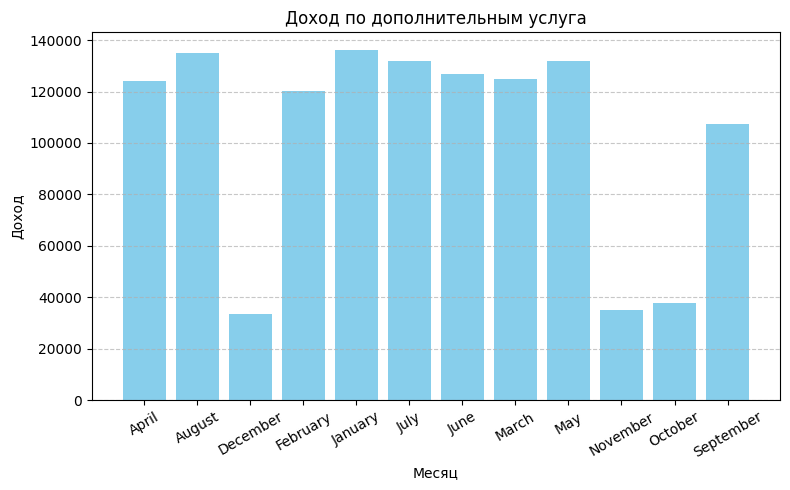

In [39]:
plt.figure(figsize=(8, 5))
plt.bar(df['Purchase Month'], df['Add-on Total'], color='skyblue')
plt.title('Доход по дополнительным услуга')
plt.xlabel('Месяц')
plt.ylabel('Доход')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 2.4 Доход по дополнительным услугам за каждый квартал

In [40]:
df = data[['Purchase Quarter', 'Add-on Total']].groupby('Purchase Quarter').agg({'Add-on Total': 'sum'}).reset_index()
df.head(10)

,Purchase Quarter,Add-on Total
0,Q1,381298.34
1,Q2,382681.69
2,Q3,374681.85
3,Q4,106235.08


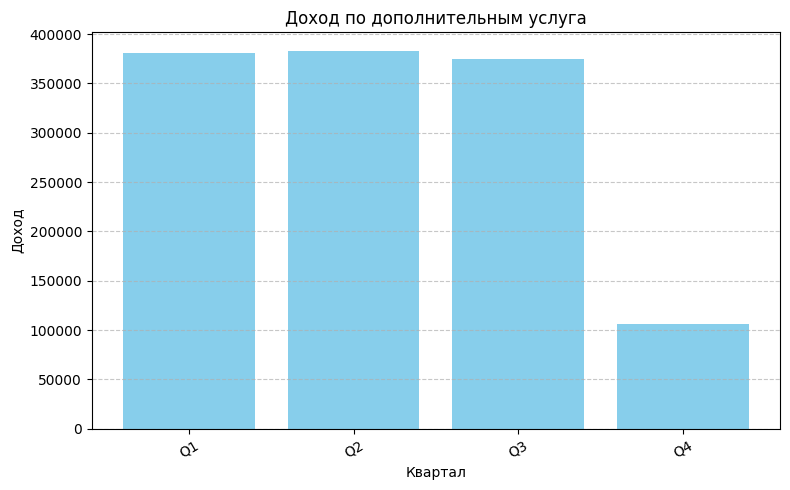

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(df['Purchase Quarter'], df['Add-on Total'], color='skyblue')
plt.title('Доход по дополнительным услуга')
plt.xlabel('Квартал')
plt.ylabel('Доход')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Чек-лист самопроверки 

| Критерии выполнения задания | Отметка о выполнении |
|---|---|
| Установлен Jupyter Notebook либо используется Google Colab | ✅ |
| Создан профиль на [github.com](https://github.com) (при использовании Jupyter Notebook) | ✅ |
| **Задание 1.**<br>Код выводит требуемые данные | ✅ |
| **Задание 2.**<br>Код выводит требуемые данные.<br>Полученные данные отображены на графике | ✅ |
| Прикреплена на учебной платформе ссылка на выполненное задание в Google Colab или GitHub (если вы использовали Jupyter Notebook) | ✅ |
| Если используется Google Colab, то по ссылке есть доступ | ⚪ |

